<a href="https://colab.research.google.com/github/MAGALAKSHMI20/peccs327/blob/main/Student_Performance_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install pandas matplotlib scikit-learn


**Data Collection**

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving student_dataset_10000_rows (1).csv to student_dataset_10000_rows (1).csv


In [4]:
# Load dataset
data = pd.read_csv('student_dataset_10000.csv')

# Display first rows
print(data.head())

# Dataset shape
print("Shape:", data.shape)

   gender race_ethnicity parental_level_of_education     lunch  \
0    male        group B             bachelor degree  standard   
1  female        group D                some college  standard   
2    male        group D             bachelor degree  standard   
3    male        group C            associate degree  standard   
4  female        group A                some college  standard   

  test_preparation_course  math_score  reading_score  writing_score  
0               completed          92             89             76  
1                    none          39             73             54  
2               completed          82             66             89  
3                    none          96             67             38  
4                    none          72             37             65  
Shape: (10000, 8)


**Data Cleaning and Preprocessing**

In [5]:
# Check missing values
print(data.isnull().sum())

# Remove duplicates
data = data.drop_duplicates()

# Fill missing values
data = data.fillna(method='ffill')

print("Cleaning completed")

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64
Cleaning completed


/tmp/ipykernel_18879/2820572082.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')


**Exploratory Data Analysis**

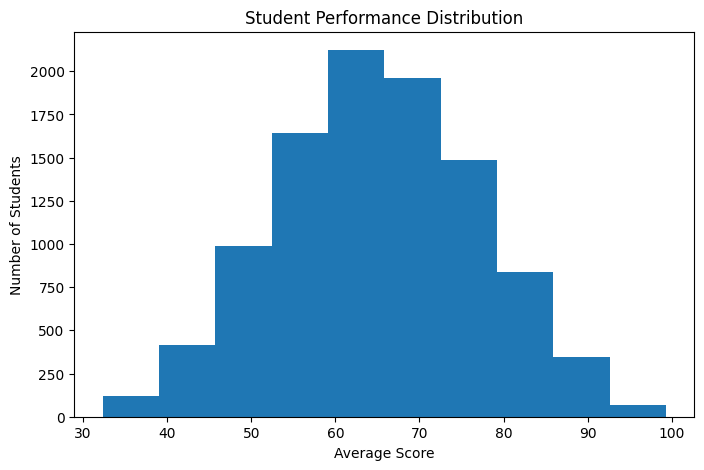

In [6]:
# Create average score
data['average_score'] = (data['math_score']+

    data['reading_score'] +
    data['writing_score']
) / 3

# Histogram
plt.figure(figsize=(8,5))
plt.hist(data['average_score'])

plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.title("Student Performance Distribution")

plt.show()


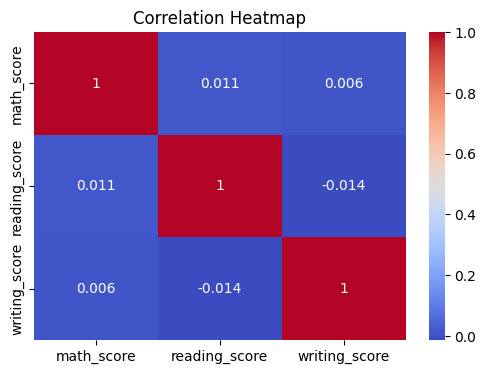

In [7]:
import seaborn as sns

# Correlation matrix
corr = data[['math_score', 'reading_score', 'writing_score']].corr()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

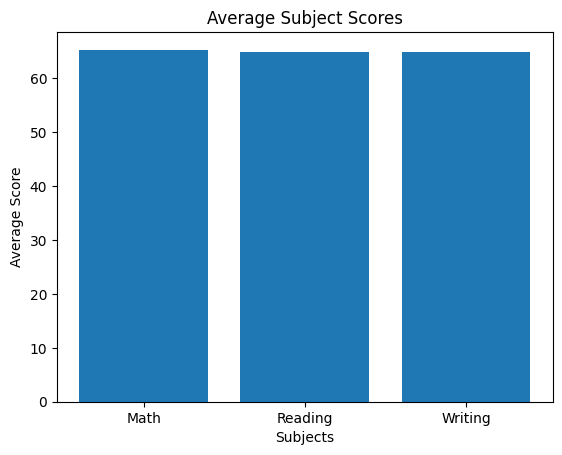

In [8]:
subjects = ['Math', 'Reading', 'Writing']

avg_scores = [
    data['math_score'].mean(),
    data['reading_score'].mean(),
    data['writing_score'].mean()
]

plt.bar(subjects, avg_scores)

plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.title("Average Subject Scores")

plt.show()

In [9]:

# Create Pass/Fail column
data['result'] = data['average_score'].apply(
    lambda x: 1 if x >= 40 else 0
)

print(data[['average_score', 'result']].head())

   average_score  result
0      85.666667       1
1      55.333333       1
2      79.000000       1
3      67.000000       1
4      58.000000       1


result
1    9853
0     146
Name: count, dtype: int64


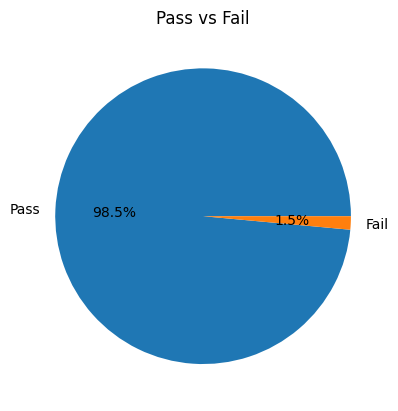

In [10]:
# Count pass and fail
result_count = data['result'].value_counts()

print(result_count)

# Pie chart
plt.pie(
    result_count,
    labels=['Pass', 'Fail'],
    autopct='%1.1f%%'
)

plt.title("Pass vs Fail")
plt.show()

        math_score  reading_score  writing_score
gender                                          
female   65.273506      64.753187      65.021315
male     65.316128      65.168307      64.799558


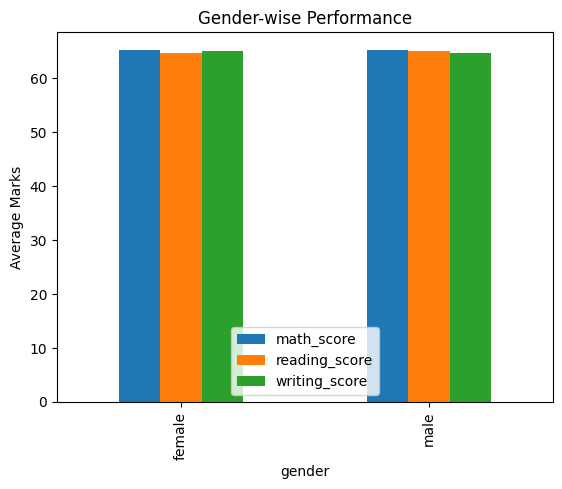

In [11]:
gender_avg = data.groupby('gender')[
    ['math_score', 'reading_score', 'writing_score']
].mean()

print(gender_avg)

gender_avg.plot(kind='bar')

plt.title("Gender-wise Performance")
plt.ylabel("Average Marks")

plt.show()

**Feature Engineering**

In [12]:
data['average_score'] = (
    data['math_score'] +
    data['reading_score'] +
    data['writing_score']
) / 3
data['result'] = data['average_score'].apply(
    lambda x: 1 if x >= 40 else 0
)

In [13]:
# Top 10 students
top_students = data.sort_values(
    by='average_score',
    ascending=False
)

print(top_students.head(10))

      gender race_ethnicity parental_level_of_education         lunch  \
438   female        group D                 high school  free/reduced   
1853    male        group E                 high school  free/reduced   
6865    male        group C                some college  free/reduced   
5021  female        group B             bachelor degree  free/reduced   
2463  female        group E                some college      standard   
8554  female        group B             bachelor degree      standard   
8649    male        group C               master degree  free/reduced   
2569  female        group D                 high school      standard   
3027  female        group A                 high school      standard   
8982    male        group D               master degree      standard   

     test_preparation_course  math_score  reading_score  writing_score  \
438                completed         100             98            100   
1853               completed          97        

**Model Building**

In [14]:

# Features and target
X = data[['math_score', 'reading_score']]
y = data['writing_score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Features
X = data[['math_score', 'reading_score', 'writing_score']]

# Target
y = data['result']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9975


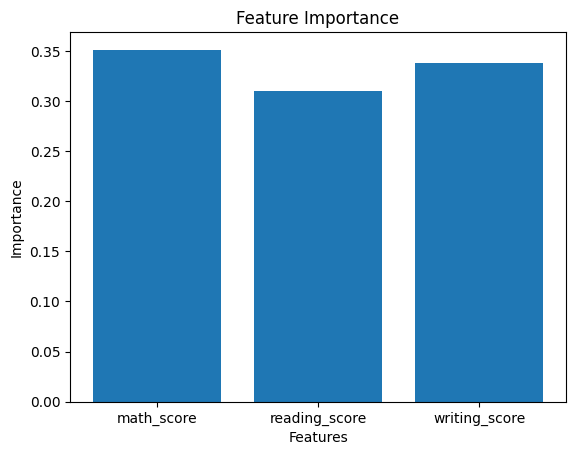

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Model
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

# Importance
importance = rf.feature_importances_

features = X.columns

# Plot
plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

**Model Evaluation**

In [26]:
# columns used during training
X_test = X_test[model.feature_names_in_]

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.998

Confusion Matrix:
[[  19    4]
 [   0 1977]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90        23
           1       1.00      1.00      1.00      1977

    accuracy                           1.00      2000
   macro avg       1.00      0.91      0.95      2000
weighted avg       1.00      1.00      1.00      2000



In [28]:
print(model.feature_names_in_)

['math_score' 'reading_score' 'writing_score']


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.998

Confusion Matrix:
 [[  19    4]
 [   0 1977]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.90        23
           1       1.00      1.00      1.00      1977

    accuracy                           1.00      2000
   macro avg       1.00      0.91      0.95      2000
weighted avg       1.00      1.00      1.00      2000



**Feature Importance**

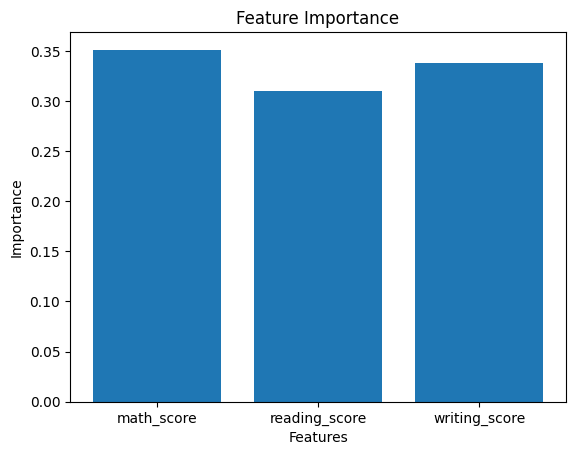

In [20]:
importance = rf.feature_importances_

features = X.columns

plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

**Prediction & Visualization**

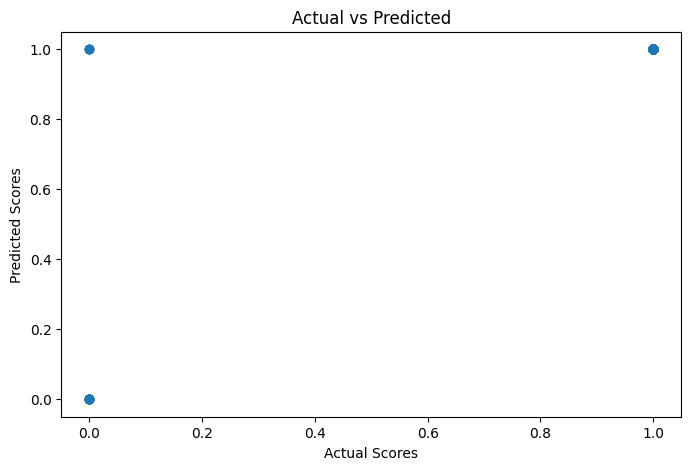

In [21]:

# Actual vs Predicted graph
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")

plt.show()

In [22]:
print("Prediction:", model.predict([[70, 80, 75]])[0])

Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**Save & Export**

In [23]:
import joblib

# Save model
joblib.dump(model, 'student_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
import joblib

loaded_model = joblib.load('student_model.pkl')

prediction = loaded_model.predict([[80, 75, 78]])

print("Prediction:", prediction[0])

Prediction: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [25]:
# Save cleaned data
data.to_csv("cleaned_student_data.csv", index=False)

print("Cleaned dataset exported")

Cleaned dataset exported
